In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [2]:
local_runtimes = pd.read_pickle("qaoa_runtimes2.pkl").copy()
colab_runtimes = pd.read_pickle("colab_runtimes.pkl").copy()
colab_runtimes2 = pd.read_pickle("colab_runtimes2.pkl").copy()

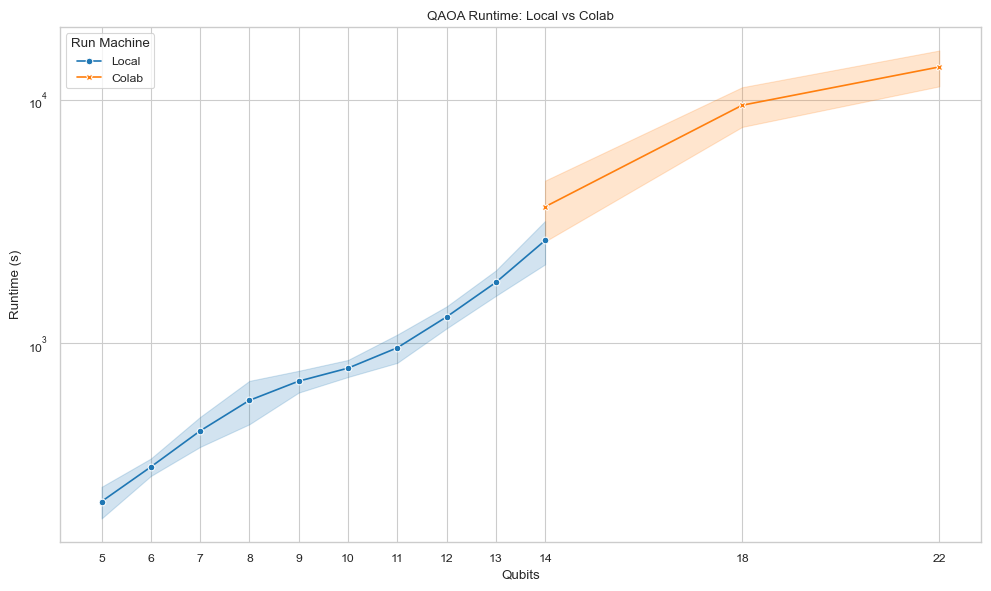

In [3]:
# Adjust colab_runtimes2 by 0.8, as they were run on a T4 instead of A100
colab_runtimes2["Time (s)"] = colab_runtimes2["Time (s)"] * 0.75

# Label source machine
local_runtimes["Run Machine"] = "Local"
colab_runtimes["Run Machine"] = "Colab"
colab_runtimes2["Run Machine"] = "Colab"

# Combine
all_runtimes = pd.concat([local_runtimes, colab_runtimes, colab_runtimes2], ignore_index=True)

# Defensive typing (helpful if notebook read types vary)
all_runtimes["Qubits"] = pd.to_numeric(all_runtimes["Qubits"], errors="coerce")
all_runtimes["Time (s)"] = pd.to_numeric(all_runtimes["Time (s)"], errors="coerce")
all_runtimes = all_runtimes.dropna(subset=["Qubits", "Time (s)"])

x_axis_vals = sorted(all_runtimes["Qubits"].unique())

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=all_runtimes,
    x="Qubits",
    y="Time (s)",
    hue="Run Machine",          # different color per machine
    style="Run Machine",        # optional: marker/line style per machine
    markers=True,
    dashes=False,
    estimator="mean",           # average over repeated runs at same qubit count
    errorbar="sd",
    palette={"Local": "#1f77b4", "Colab": "#ff7f0e"},
)

plt.yscale('log')

plt.xticks(x_axis_vals)
plt.xlabel("Qubits")
plt.ylabel("Runtime (s)")
plt.title("QAOA Runtime: Local vs Colab")
plt.legend(title="Run Machine")
plt.tight_layout()
plt.savefig("plots/local_vs_colab_runtimes.svg", dpi=300, bbox_inches="tight")
plt.show()